# Deploying scikit-learn Models in Production

Notebook ini membahas **deployment model scikit-learn ke lingkungan produksi**. Fokus utama chapter ini adalah bagaimana model yang sudah dilatih dapat disimpan, dimuat ulang, divalidasi, dipantau, dan dikelola sebagai artifact produksi.

Materi utama:
- Overview of model deployment
- Serialization dan persistence dengan `joblib` dan `pickle`
- Simulasi prediction endpoint
- Benchmark latency dan throughput
- Scaling model untuk production
- Monitoring dan updating deployed model
- Model life cycle management
- Metadata, versioning, validation snapshot
- Deployment pipeline dan CI/CD/CT logic
- Practical exercises model deployment

## Tujuan Pembelajaran

Setelah mempelajari notebook ini, pembaca diharapkan mampu:

- Memahami konsep dasar deployment model machine learning.
- Menjelaskan perbedaan training environment dan production environment.
- Menyimpan model scikit-learn menggunakan `joblib` dan `pickle`.
- Memuat ulang model yang sudah diserialisasi.
- Memastikan model hasil load menghasilkan prediksi yang konsisten.
- Mengukur latency dan throughput inference.
- Membandingkan single prediction dan batch prediction.
- Menggunakan `n_jobs` untuk parallel processing.
- Memahami monitoring model setelah deployment.
- Mensimulasikan data streaming dan batch accuracy monitoring.
- Menggunakan `partial_fit()` untuk update model incremental.
- Menyimpan metadata model, versi library, dan validation snapshot.
- Membuat deployment gate sederhana berbasis threshold performa.
- Memahami konsep CI/CD/CT dalam machine learning.

## Persiapan Library

Cell berikut memuat library yang digunakan. Warning diabaikan agar output notebook tetap bersih ketika dijalankan.

In [1]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

import os
import json
import time
import pickle
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
from joblib import dump, load

from sklearn.datasets import make_classification, load_iris
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

np.random.seed(2024)
pd.set_option("display.max_columns", 120)

ARTIFACT_DIR = Path("model_artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

## Ringkasan Chapter

Deployment model berarti memindahkan model dari lingkungan pengembangan ke lingkungan produksi agar prediksi model bisa digunakan oleh sistem, aplikasi, atau pengguna nyata. Model yang hanya tersimpan di notebook belum memberi nilai bisnis jika tidak bisa dijalankan secara stabil di luar eksperimen.

Chapter ini menekankan bahwa deployment tidak hanya tentang menyimpan file model. Deployment juga mencakup artifact management, performance validation, serving design, monitoring, retraining, versioning, dan pipeline automation.

| Topik | Inti Pembahasan |
|---|---|
| Model Deployment | Memindahkan model dari development ke production |
| Serialization | Mengubah model menjadi artifact yang bisa disimpan |
| Persistence | Menyimpan dan memuat ulang model |
| Scaling | Mengoptimalkan inference untuk beban produksi |
| Monitoring | Memantau performa model setelah live |
| Model Life Cycle | Mengelola versi model, metadata, validasi, dan rollback |
| Deployment Pipeline | Mengotomatisasi training, validation, export, dan deployment |
| CI/CD/CT | Continuous Integration, Continuous Deployment, dan Continuous Training |

Dalam praktik nyata, deployment ML juga melibatkan aspek non-teknis seperti target ROI, business threshold, risiko kesalahan prediksi, governance, dan kebutuhan retraining.

## Overview of Model Deployment

Model deployment adalah proses membawa model machine learning dari notebook atau development environment ke production environment. Setelah deployment, model dapat menerima input baru dan menghasilkan prediksi untuk aplikasi nyata.

Contoh bentuk deployment:

- REST API untuk real-time prediction.
- Batch prediction pipeline untuk data harian/mingguan.
- Serverless function untuk inference ringan.
- Embedded model di aplikasi internal.
- Scheduled scoring pipeline untuk laporan bisnis.

Komponen penting deployment:

| Komponen | Fungsi |
|---|---|
| Model artifact | File model hasil training |
| Preprocessing logic | Transformasi input sebelum prediksi |
| Serving layer | API atau sistem yang menerima request |
| Validation check | Pengujian bahwa model masih valid |
| Monitoring | Pemantauan performa dan drift |
| Retraining logic | Mekanisme update model |
| Metadata | Informasi versi, library, dataset, dan skor validasi |

## Workflow Umum Deployment Model

Alur sederhana deployment model:

1. Train model di development environment.
2. Evaluasi model menggunakan validation/test data.
3. Simpan model sebagai artifact.
4. Simpan metadata model.
5. Load artifact di production-like environment.
6. Jalankan smoke test atau validation check.
7. Deploy model jika memenuhi threshold.
8. Monitor performa model.
9. Retrain atau rollback jika model menurun.

Secara konseptual:

$$
Training \rightarrow Validation \rightarrow Serialization \rightarrow Deployment \rightarrow Monitoring \rightarrow Retraining
$$

Alur ini menunjukkan bahwa deployment bukan tahap akhir, tetapi bagian dari siklus hidup model.

## Membuat Model Baseline untuk Deployment

Kita membuat dataset klasifikasi sintetis dan melatih Logistic Regression sebagai model baseline. Model ini nantinya akan disimpan, dimuat ulang, dan diuji seperti skenario production.

In [2]:
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=12,
    n_redundant=4,
    random_state=2024
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=2024,
    stratify=y
)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Shape training:", X_train.shape)
print("Shape testing:", X_test.shape)

Test accuracy: 0.62
Shape training: (750, 20)
Shape testing: (250, 20)


## Serialization dengan joblib

`joblib` adalah cara yang umum direkomendasikan untuk menyimpan model scikit-learn karena lebih efisien untuk object yang mengandung array NumPy besar.

Proses dasar:

```python
dump(model, "model.joblib")
loaded_model = load("model.joblib")
```

Setelah model dimuat ulang, model harus menghasilkan prediksi yang sama untuk input yang sama.

In [3]:
model_path = ARTIFACT_DIR / "logistic_model.joblib"

dump(clf, model_path)

clf_loaded = load(model_path)

sample_input = X_test[:5]

original_pred = clf.predict(sample_input)
loaded_pred = clf_loaded.predict(sample_input)

comparison_df = pd.DataFrame({
    "original_prediction": original_pred,
    "loaded_prediction": loaded_pred,
    "same": original_pred == loaded_pred
})

print("Model saved to:", model_path)
comparison_df

Model saved to: model_artifacts\logistic_model.joblib


,original_prediction,loaded_prediction,same
0,0,0,True
1,0,0,True
2,1,1,True
3,1,1,True
4,0,0,True


## Verifikasi Konsistensi Model

Model hasil load harus konsisten dengan model original. Jika prediksi berubah setelah serialization, berarti ada masalah pada artifact, dependency, environment, atau preprocessing.

In [4]:
assert np.array_equal(original_pred, loaded_pred)

print("Prediksi model original dan loaded model konsisten.")

Prediksi model original dan loaded model konsisten.


## Simulasi Prediction Endpoint

Pada production system, model biasanya tidak dipanggil langsung dari notebook. Model akan dimuat oleh service/API, lalu menerima request input.

Fungsi berikut mensimulasikan endpoint sederhana:

1. Input diterima sebagai array.
2. Model melakukan prediksi.
3. Output dikembalikan sebagai dictionary.

In [5]:
def predict_endpoint(model, input_array):
    input_array = np.asarray(input_array)

    if input_array.ndim == 1:
        input_array = input_array.reshape(1, -1)

    prediction = model.predict(input_array)

    response = {
        "n_inputs": int(input_array.shape[0]),
        "prediction": prediction.tolist()
    }

    if hasattr(model, "predict_proba"):
        response["probability"] = model.predict_proba(input_array).round(4).tolist()

    return response

single_response = predict_endpoint(clf_loaded, X_test[0])
batch_response = predict_endpoint(clf_loaded, X_test[:3])

print("Single response:")
print(single_response)

print("\nBatch response:")
print(batch_response)

Single response:
{'n_inputs': 1, 'prediction': [0], 'probability': [[0.5864, 0.4136]]}

Batch response:
{'n_inputs': 3, 'prediction': [0, 0, 1], 'probability': [[0.5864, 0.4136], [0.5855, 0.4145], [0.342, 0.658]]}


## Latency dan Throughput

Dalam deployment, performa model bukan hanya accuracy. Sistem produksi juga perlu mempertimbangkan latency dan throughput.

| Istilah | Penjelasan |
|---|---|
| Latency | Waktu yang dibutuhkan untuk melayani satu request |
| Throughput | Jumlah prediksi yang dapat diproses per detik |
| Batch prediction | Prediksi banyak data sekaligus |
| Single prediction | Prediksi satu data per request |

Rumus throughput:

$$
Throughput = \frac{Jumlah\ Prediksi}{Total\ Waktu}
$$

Batch prediction biasanya lebih efisien karena memanfaatkan optimasi vektor/matriks pada NumPy dan scikit-learn.

## Benchmark Single vs Batch Prediction

Kita membandingkan waktu prediksi satu per satu dengan prediksi batch.

In [6]:
benchmark_data = X_test[:200]

# Single prediction loop
start_single = time.perf_counter()
single_preds = []
for row in benchmark_data:
    single_preds.append(clf_loaded.predict(row.reshape(1, -1))[0])
single_time = time.perf_counter() - start_single

# Batch prediction
start_batch = time.perf_counter()
batch_preds = clf_loaded.predict(benchmark_data)
batch_time = time.perf_counter() - start_batch

benchmark_df = pd.DataFrame({
    "Mode": ["Single prediction loop", "Batch prediction"],
    "Total Predictions": [len(benchmark_data), len(benchmark_data)],
    "Total Time Seconds": [single_time, batch_time],
    "Throughput Predictions per Second": [
        len(benchmark_data) / single_time,
        len(benchmark_data) / batch_time
    ]
})

benchmark_df

,Mode,Total Predictions,Total Time Seconds,Throughput Predictions per Second
0,Single prediction loop,200,0.083974,2381.695243
1,Batch prediction,200,0.000669,298953.661769


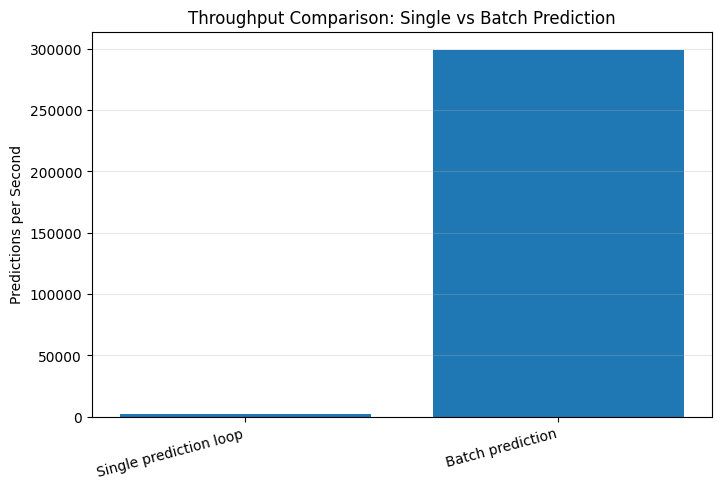

In [7]:
plt.figure(figsize=(8, 5))
plt.bar(benchmark_df["Mode"], benchmark_df["Throughput Predictions per Second"])
plt.ylabel("Predictions per Second")
plt.title("Throughput Comparison: Single vs Batch Prediction")
plt.xticks(rotation=15, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.show()

## Analisis Benchmark

Batch prediction biasanya jauh lebih cepat dibanding memanggil prediksi satu per satu dalam loop Python. Hal ini terjadi karena overhead function call berkurang dan operasi numerik dapat dilakukan secara vektorisasi.

Untuk production system:
- Real-time API cocok untuk request individual.
- Batch prediction cocok untuk scoring data besar secara periodik.
- Jika request real-time sangat banyak, sistem bisa menggabungkan request dalam micro-batch.

## Serialization and Persistence Techniques

Selain `joblib`, Python juga menyediakan `pickle`. Keduanya dapat menyimpan object model, tetapi `joblib` biasanya lebih efisien untuk scikit-learn estimator karena banyak estimator memakai array NumPy.

Perbandingan:

| Teknik | Kelebihan | Kekurangan |
|---|---|---|
| joblib | Efisien untuk array besar, umum untuk scikit-learn | Tetap bergantung pada versi library |
| pickle | Built-in Python, fleksibel | Risiko keamanan, bisa kurang efisien |
| ONNX | Bisa digunakan di environment non-Python | Tidak semua estimator/transformer didukung |
| PMML | Format interoperable untuk sebagian model | Dukungan terbatas dan setup tambahan |

Catatan keamanan penting: jangan pernah melakukan `pickle.load()` atau `joblib.load()` pada file yang tidak terpercaya.

## Serialization dengan pickle dan joblib

Contoh berikut menyimpan Random Forest menggunakan dua format, lalu memastikan prediksi tetap identik setelah model dimuat ulang.

In [8]:
X_rf, y_rf = make_classification(
    n_samples=500,
    n_features=15,
    n_informative=10,
    random_state=2024
)

rf = RandomForestClassifier(
    n_estimators=10,
    random_state=2024
)

rf.fit(X_rf, y_rf)

pickle_path = ARTIFACT_DIR / "rf.pkl"
joblib_path = ARTIFACT_DIR / "rf.joblib"

# Serialize using pickle
with open(pickle_path, "wb") as f:
    pickle.dump(rf, f)

# Serialize using joblib
dump(rf, joblib_path)

# Load pickle
with open(pickle_path, "rb") as f:
    rf_pickle_loaded = pickle.load(f)

# Load joblib
rf_joblib_loaded = load(joblib_path)

pred_original = rf.predict(X_rf[:10])
pred_pickle = rf_pickle_loaded.predict(X_rf[:10])
pred_joblib = rf_joblib_loaded.predict(X_rf[:10])

serialization_check = pd.DataFrame({
    "original": pred_original,
    "pickle_loaded": pred_pickle,
    "joblib_loaded": pred_joblib,
    "pickle_same": pred_original == pred_pickle,
    "joblib_same": pred_original == pred_joblib
})

serialization_check

,original,pickle_loaded,joblib_loaded,pickle_same,joblib_same
0,1,1,1,True,True
1,1,1,1,True,True
2,0,0,0,True,True
3,0,0,0,True,True
4,0,0,0,True,True
5,1,1,1,True,True
6,0,0,0,True,True
7,0,0,0,True,True
8,1,1,1,True,True
9,0,0,0,True,True


In [9]:
assert np.array_equal(pred_original, pred_pickle)
assert np.array_equal(pred_original, pred_joblib)

file_sizes = pd.DataFrame({
    "File": [pickle_path.name, joblib_path.name],
    "Size KB": [
        pickle_path.stat().st_size / 1024,
        joblib_path.stat().st_size / 1024
    ]
})

file_sizes

,File,Size KB
0,rf.pkl,105.058594
1,rf.joblib,105.946289


## Analisis Persistence

Serialization menyimpan model sebagai artifact agar dapat digunakan kembali tanpa training ulang. Namun, model artifact perlu dikelola dengan hati-hati.

Best practice:
- Simpan model dengan nama versi.
- Simpan dependency version.
- Simpan validation score.
- Simpan schema input.
- Simpan training configuration.
- Jangan load artifact dari sumber tidak terpercaya.
- Validasi ulang artifact setelah upgrade library.

## Scaling Models for Production

Scaling model production berkaitan dengan kemampuan sistem menangani beban inference dan training. Scikit-learn menyediakan beberapa cara sederhana:

| Teknik | Penjelasan |
|---|---|
| `n_jobs=-1` | Menggunakan semua core CPU yang tersedia |
| Batch prediction | Mengurangi overhead request individual |
| Parallel CV | Mempercepat cross-validation |
| Incremental learning | Update model dengan data baru menggunakan `partial_fit()` |
| Distributed backend | Menggunakan Dask atau sistem lain untuk workload besar |

Tidak semua estimator mendukung `n_jobs`, dan tidak semua model cocok untuk incremental learning.

## Benchmark Random Forest dengan Batch Prediction

Kita membuat model Random Forest dan mengukur latency prediksi batch.

In [10]:
X_scale, y_scale = make_classification(
    n_samples=2000,
    n_features=50,
    n_informative=30,
    random_state=2024
)

rf_scale = RandomForestClassifier(
    n_estimators=100,
    n_jobs=-1,
    random_state=2024
)

rf_scale.fit(X_scale, y_scale)

batch_sizes = [1, 10, 100, 500, 1000]
latency_results = []

for batch_size in batch_sizes:
    batch = np.random.rand(batch_size, 50)
    start = time.perf_counter()
    rf_scale.predict(batch)
    elapsed = time.perf_counter() - start

    latency_results.append({
        "batch_size": batch_size,
        "total_time_seconds": elapsed,
        "latency_per_sample_ms": (elapsed / batch_size) * 1000,
        "throughput_per_second": batch_size / elapsed
    })

latency_df = pd.DataFrame(latency_results)
latency_df

,batch_size,total_time_seconds,latency_per_sample_ms,throughput_per_second
0,1,0.063854,63.853600,15.660824
1,10,0.052680,5.268040,189.823919
2,100,0.058660,0.586598,1704.744987
3,500,0.057723,0.115447,8661.998427
4,1000,0.068867,0.068867,14520.848308


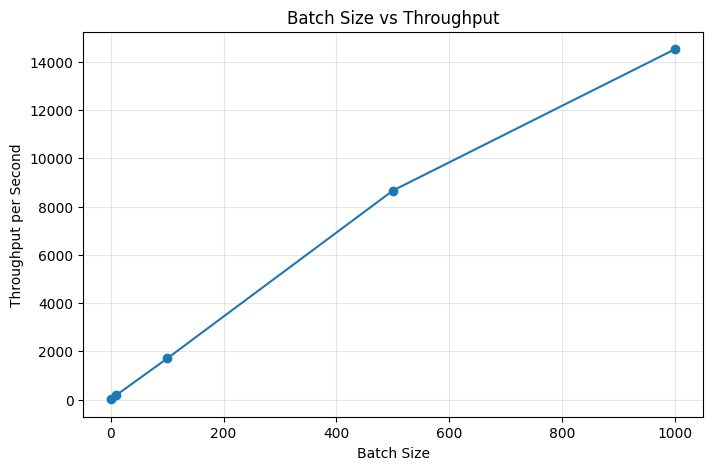

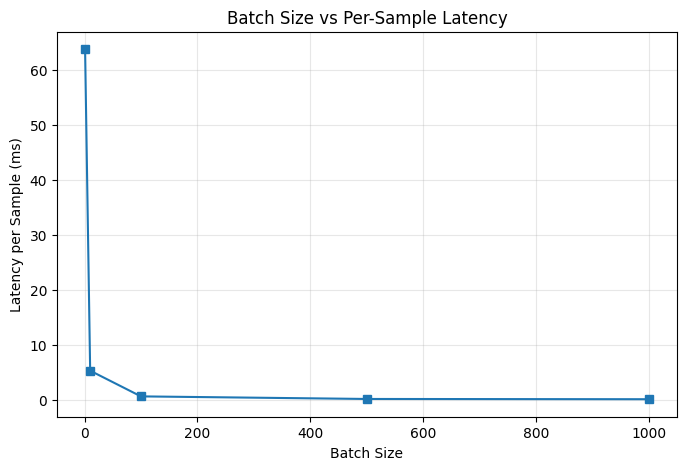

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(latency_df["batch_size"], latency_df["throughput_per_second"], marker="o")
plt.xlabel("Batch Size")
plt.ylabel("Throughput per Second")
plt.title("Batch Size vs Throughput")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(latency_df["batch_size"], latency_df["latency_per_sample_ms"], marker="s")
plt.xlabel("Batch Size")
plt.ylabel("Latency per Sample (ms)")
plt.title("Batch Size vs Per-Sample Latency")
plt.grid(alpha=0.3)
plt.show()

## Parallel Cross-Validation

`n_jobs=-1` juga dapat digunakan pada `cross_val_score()` untuk menjalankan fold secara paralel, tergantung estimator dan environment.

In [12]:
start_cv = time.perf_counter()

scores = cross_val_score(
    RandomForestClassifier(n_estimators=50, random_state=2024),
    X_scale,
    y_scale,
    cv=3,
    n_jobs=-1
)

cv_time = time.perf_counter() - start_cv

print("CV Accuracy:", scores)
print("Mean CV Accuracy:", np.mean(scores))
print("CV Time Seconds:", cv_time)

CV Accuracy: [0.82608696 0.83358321 0.83033033]
Mean CV Accuracy: 0.8300001650826238
CV Time Seconds: 10.971030299999256


## Monitoring and Updating Deployed Models

Setelah model live, performa model dapat menurun karena data berubah. Perubahan ini sering disebut **data drift** atau **concept drift**.

| Jenis Perubahan | Penjelasan |
|---|---|
| Data Drift | Distribusi input berubah |
| Concept Drift | Hubungan antara input dan target berubah |
| Prediction Drift | Distribusi output prediksi berubah |
| Performance Drift | Metrik model menurun |

Monitoring membantu mendeteksi kapan model perlu ditinjau ulang, retrain, rollback, atau diganti.

## Rumus Batch Accuracy

Jika setiap batch memiliki label aktual, batch accuracy dapat dihitung sebagai:

$$
Accuracy_{batch} = \frac{Jumlah\ Prediksi\ Benar}{Jumlah\ Data\ Dalam\ Batch}
$$

Untuk batch ke-$t$:

$$
Accuracy_t = \frac{1}{n_t}\sum_{i=1}^{n_t} I(\hat{y}_{i}=y_i)
$$

Keterangan:

- $n_t$ = jumlah data dalam batch ke-$t$
- $\hat{y}_i$ = prediksi model
- $y_i$ = label aktual
- $I$ = fungsi indikator

## Simulasi Streaming Data dan Incremental Update

Contoh berikut menggunakan `SGDClassifier` karena mendukung `partial_fit()`. Model dilatih pada data awal, kemudian menerima beberapa batch data baru.

In [13]:
X_initial, y_initial = make_classification(
    n_samples=500,
    n_features=10,
    n_informative=7,
    random_state=2024
)

X_stream, y_stream = make_classification(
    n_samples=400,
    n_features=10,
    n_informative=7,
    random_state=2025
)

stream_batches = np.array_split(X_stream, 4)
stream_labels = np.array_split(y_stream, 4)

sgd_clf = SGDClassifier(
    loss="log_loss",
    random_state=2024,
    warm_start=True
)

sgd_clf.partial_fit(
    X_initial,
    y_initial,
    classes=np.unique(y_initial)
)

batch_scores = []

for xb, yb in zip(stream_batches, stream_labels):
    y_batch_pred = sgd_clf.predict(xb)
    batch_acc = np.mean(y_batch_pred == yb)
    batch_scores.append(batch_acc)

batch_scores

[np.float64(0.56), np.float64(0.54), np.float64(0.5), np.float64(0.55)]

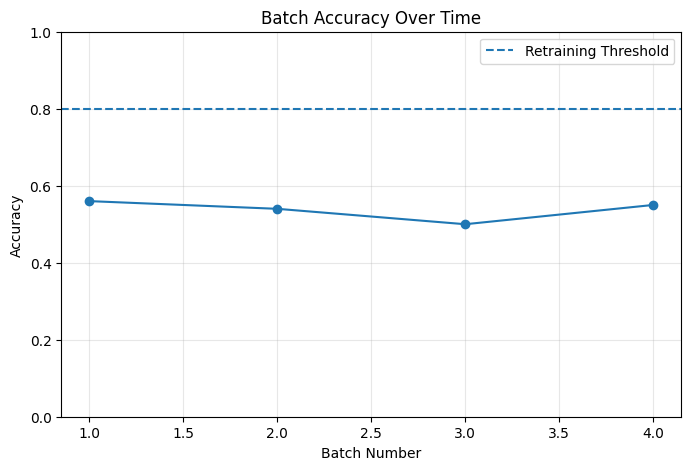

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(batch_scores) + 1), batch_scores, marker="o")
plt.axhline(0.8, linestyle="--", label="Retraining Threshold")
plt.title("Batch Accuracy Over Time")
plt.xlabel("Batch Number")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Trigger Retraining Berdasarkan Threshold

Jika akurasi batch turun di bawah threshold tertentu, pipeline dapat memicu update model. Threshold ini biasanya tidak hanya teknis, tetapi juga dipengaruhi business rule.

In [15]:
threshold = 0.8

retrain_triggered = min(batch_scores) < threshold

if retrain_triggered:
    sgd_clf.partial_fit(X_stream, y_stream)
    message = "Retraining triggered because at least one batch fell below threshold."
else:
    message = "No retraining needed."

print(message)
print("Minimum batch accuracy:", min(batch_scores))

Retraining triggered because at least one batch fell below threshold.
Minimum batch accuracy: 0.5


## Monitoring Distribution Drift Sederhana

Selain accuracy, kita juga dapat memantau distribusi fitur. Salah satu cara sederhana adalah membandingkan rata-rata fitur pada training data dan incoming batch.

In [16]:
train_mean = X_initial.mean(axis=0)

drift_rows = []

for idx, xb in enumerate(stream_batches, start=1):
    batch_mean = xb.mean(axis=0)
    mean_abs_shift = np.mean(np.abs(batch_mean - train_mean))
    drift_rows.append({
        "batch": idx,
        "mean_absolute_feature_shift": mean_abs_shift,
        "batch_accuracy": batch_scores[idx - 1]
    })

drift_df = pd.DataFrame(drift_rows)
drift_df

,batch,mean_absolute_feature_shift,batch_accuracy
0,1,0.568928,0.56
1,2,0.378898,0.54
2,3,0.445868,0.50
3,4,0.469085,0.55


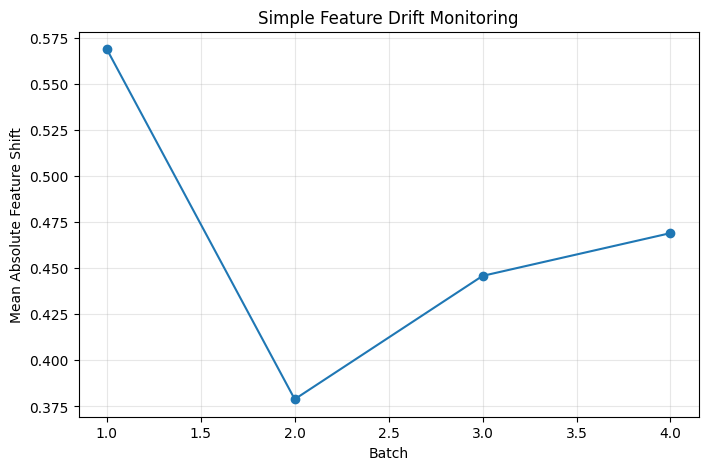

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(drift_df["batch"], drift_df["mean_absolute_feature_shift"], marker="o")
plt.xlabel("Batch")
plt.ylabel("Mean Absolute Feature Shift")
plt.title("Simple Feature Drift Monitoring")
plt.grid(alpha=0.3)
plt.show()

## Managing the Model Life Cycle

Model life cycle management memastikan model tetap reliable, reproducible, dan maintainable.

Komponen penting:

| Komponen | Penjelasan |
|---|---|
| Model version | Versi artifact model |
| Metadata | Informasi library, data, parameter, skor |
| Validation snapshot | Skor dan prediksi pada validation set |
| Input schema | Struktur fitur yang diharapkan |
| Rollback plan | Cara kembali ke model sebelumnya |
| Retraining schedule | Kapan model dilatih ulang |
| Approval gate | Kondisi model boleh deploy |

Model tidak boleh dianggap selesai setelah training. Dalam produksi, model perlu dipantau dan diperbarui.

## Menyimpan Model dengan Metadata

Kita menyimpan Random Forest sebagai artifact versi `v1.0`, lalu menyimpan metadata dalam file JSON.

In [18]:
X_life, y_life = make_classification(
    n_samples=800,
    n_features=20,
    n_informative=12,
    random_state=2024
)

X_train_life, X_val_life, y_train_life, y_val_life = train_test_split(
    X_life,
    y_life,
    test_size=0.25,
    random_state=2024,
    stratify=y_life
)

life_model = RandomForestClassifier(
    n_estimators=50,
    random_state=2024
)

life_model.fit(X_train_life, y_train_life)

val_pred_life = life_model.predict(X_val_life)
val_acc_life = accuracy_score(y_val_life, val_pred_life)

version = "v1.0"

life_model_path = ARTIFACT_DIR / f"rf_{version}.joblib"
metadata_path = ARTIFACT_DIR / f"rf_{version}_metadata.json"
validation_path = ARTIFACT_DIR / f"rf_{version}_validation.json"

dump(life_model, life_model_path)

metadata = {
    "model_name": "RandomForestClassifier",
    "version": version,
    "sklearn_version": sklearn.__version__,
    "numpy_version": np.__version__,
    "python_version": platform.python_version(),
    "n_features": int(X_life.shape[1]),
    "n_train_samples": int(X_train_life.shape[0]),
    "n_validation_samples": int(X_val_life.shape[0]),
    "random_state": 2024
}

validation_snapshot = {
    "validation_accuracy": float(val_acc_life),
    "validation_predictions_first_20": val_pred_life[:20].tolist(),
    "validation_labels_first_20": y_val_life[:20].tolist()
}

with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

with open(validation_path, "w") as f:
    json.dump(validation_snapshot, f, indent=4)

print("Saved model:", life_model_path)
print("Saved metadata:", metadata_path)
print("Saved validation snapshot:", validation_path)
print("Validation accuracy:", val_acc_life)

Saved model: model_artifacts\rf_v1.0.joblib
Saved metadata: model_artifacts\rf_v1.0_metadata.json
Saved validation snapshot: model_artifacts\rf_v1.0_validation.json
Validation accuracy: 0.81


## Membaca Metadata Artifact

Metadata membantu audit dan reproducibility. Jika model bermasalah di masa depan, metadata dapat digunakan untuk melacak versi, environment, dan performa saat model dipromosikan.

In [19]:
with open(metadata_path, "r") as f:
    loaded_metadata = json.load(f)

with open(validation_path, "r") as f:
    loaded_validation = json.load(f)

display(pd.DataFrame([loaded_metadata]))
display(pd.DataFrame([loaded_validation]).T)

,model_name,version,sklearn_version,numpy_version,python_version,n_features,n_train_samples,n_validation_samples,random_state
0,RandomForestClassifier,v1.0,1.9.0,2.3.1,3.13.5,20,600,200,2024


,0
validation_accuracy,0.81
validation_predictions_first_20,"[1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, ..."
validation_labels_first_20,"[1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, ..."


## Setting up Deployment Pipelines

Deployment pipeline menggabungkan preprocessing, model, serialization, validation, dan gating logic. Dalam scikit-learn, `Pipeline` sangat penting karena memastikan preprocessing dan model tersimpan dalam satu artifact.

Tanpa pipeline, ada risiko:
- model dipakai tanpa scaling,
- urutan preprocessing berbeda,
- feature mismatch,
- training-serving skew,
- data leakage.

Pipeline membantu menyatukan inference logic agar konsisten antara training dan production.

## Membuat dan Menyimpan Pipeline

Contoh berikut menggunakan `StandardScaler` dan `LogisticRegression` dalam satu pipeline.

In [20]:
X_pipe, y_pipe = make_classification(
    n_samples=500,
    n_features=10,
    n_informative=7,
    random_state=2024
)

X_train_pipe, X_test_pipe, y_train_pipe, y_test_pipe = train_test_split(
    X_pipe,
    y_pipe,
    test_size=0.3,
    random_state=2024,
    stratify=y_pipe
)

pipe = Pipeline([
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])

pipe.fit(X_train_pipe, y_train_pipe)

pipeline_path = ARTIFACT_DIR / "pipeline.joblib"
dump(pipe, pipeline_path)

prod_pipe = load(pipeline_path)

pipe_pred = prod_pipe.predict(X_test_pipe)
pipe_acc = accuracy_score(y_test_pipe, pipe_pred)

print("Pipeline saved:", pipeline_path)
print("Validation accuracy:", pipe_acc)

Pipeline saved: model_artifacts\pipeline.joblib
Validation accuracy: 0.8066666666666666


## Deployment Gate Berbasis Threshold

Deployment gate adalah aturan otomatis untuk menentukan apakah model boleh dipromosikan ke production.

Contoh sederhana:

$$
Deploy =
\begin{cases}
Allowed, & \text{jika } Accuracy \ge Threshold \\
Halted, & \text{jika } Accuracy < Threshold
\end{cases}
$$

Threshold harus disesuaikan dengan kebutuhan bisnis. Tidak semua aplikasi membutuhkan threshold yang sama.

In [21]:
deployment_threshold = 0.80

if pipe_acc >= deployment_threshold:
    deployment_status = "Auto-deploy allowed"
else:
    deployment_status = "Halt deployment and review"

deployment_check = pd.DataFrame({
    "metric": ["accuracy"],
    "value": [pipe_acc],
    "threshold": [deployment_threshold],
    "status": [deployment_status]
})

deployment_check

,metric,value,threshold,status
0,accuracy,0.806667,0.8,Auto-deploy allowed


## Simulasi CI/CD Check

CI/CD check dapat memuat artifact, mengecek schema input, menghitung metrik validasi, dan memutuskan apakah model layak deploy.

In [22]:
def ci_cd_validation_check(model_path, X_validation, y_validation, threshold=0.80):
    loaded_pipeline = load(model_path)

    predictions = loaded_pipeline.predict(X_validation)
    accuracy = accuracy_score(y_validation, predictions)

    result = {
        "artifact": str(model_path),
        "accuracy": float(accuracy),
        "threshold": float(threshold),
        "passed": bool(accuracy >= threshold)
    }

    return result

ci_result = ci_cd_validation_check(
    pipeline_path,
    X_test_pipe,
    y_test_pipe,
    threshold=0.80
)

ci_result

{'artifact': 'model_artifacts\\pipeline.joblib',
 'accuracy': 0.8066666666666666,
 'threshold': 0.8,
 'passed': True}

## Practical Exercise 1: Saving and Reloading a Pipeline

Latihan ini memastikan preprocessing dan model tersimpan dalam satu artifact, lalu artifact dapat dimuat ulang untuk menghasilkan prediksi baru.

In [23]:
exercise_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

exercise_pipe.fit(X_train_pipe, y_train_pipe)

exercise_path = ARTIFACT_DIR / "exercise_pipeline.joblib"

dump(exercise_pipe, exercise_path)

reloaded_exercise_pipe = load(exercise_path)

new_samples = X_test_pipe[:5]
new_predictions = reloaded_exercise_pipe.predict(new_samples)

pd.DataFrame({
    "sample_index": range(len(new_predictions)),
    "prediction": new_predictions
})

,sample_index,prediction
0,0,1
1,1,1
2,2,0
3,3,0
4,4,0


## Practical Exercise 2: Monitoring Accuracy Over Time

Latihan ini mensimulasikan batch data yang masuk secara bertahap dan memantau akurasi setiap batch.

In [24]:
monitor_model = SGDClassifier(
    loss="log_loss",
    random_state=2024,
    warm_start=True
)

monitor_model.partial_fit(
    X_initial,
    y_initial,
    classes=np.unique(y_initial)
)

monitor_scores = []

for batch_id, (xb, yb) in enumerate(zip(stream_batches, stream_labels), start=1):
    pred = monitor_model.predict(xb)
    acc = accuracy_score(yb, pred)
    monitor_scores.append({
        "batch": batch_id,
        "accuracy": acc,
        "below_threshold": acc < threshold
    })

monitor_df = pd.DataFrame(monitor_scores)
monitor_df

,batch,accuracy,below_threshold
0,1,0.56,True
1,2,0.54,True
2,3,0.50,True
3,4,0.55,True


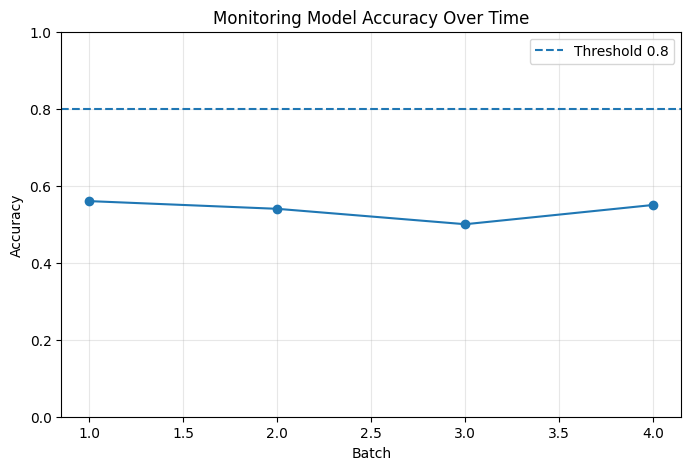

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(monitor_df["batch"], monitor_df["accuracy"], marker="o")
plt.axhline(threshold, linestyle="--", label=f"Threshold {threshold}")
plt.xlabel("Batch")
plt.ylabel("Accuracy")
plt.title("Monitoring Model Accuracy Over Time")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Practical Exercise 3: Automating Deployment Checks

Latihan ini membuat deployment rule sederhana: model hanya dapat dipromosikan jika skor validasi memenuhi threshold.

In [26]:
def approve_or_reject_deployment(validation_metric, threshold):
    if validation_metric >= threshold:
        return "APPROVED"
    return "REJECTED"

approval_result = approve_or_reject_deployment(pipe_acc, deployment_threshold)

deployment_summary = pd.DataFrame({
    "model_artifact": [pipeline_path.name],
    "validation_accuracy": [pipe_acc],
    "threshold": [deployment_threshold],
    "deployment_decision": [approval_result]
})

deployment_summary

,model_artifact,validation_accuracy,threshold,deployment_decision
0,pipeline.joblib,0.806667,0.8,APPROVED


## Best Practices Deployment scikit-learn

| Praktik | Alasan |
|---|---|
| Simpan preprocessing dan model dalam Pipeline | Menghindari training-serving skew |
| Gunakan joblib untuk model scikit-learn | Efisien untuk NumPy/scikit-learn objects |
| Simpan metadata | Reproducibility dan audit |
| Simpan validation snapshot | Mengecek konsistensi artifact |
| Benchmark latency dan throughput | Mengetahui kesiapan serving |
| Gunakan batch prediction jika memungkinkan | Throughput lebih baik |
| Monitor performa setelah deployment | Model bisa degrade |
| Buat retraining trigger | Menghadapi drift |
| Gunakan deployment threshold | Mencegah model buruk masuk production |
| Siapkan rollback plan | Mengurangi risiko deployment gagal |

Deployment ML harus dilihat sebagai sistem yang terus berjalan, bukan satu kali export file.

## Kesalahan Umum dalam Model Deployment

| Kesalahan | Dampak |
|---|---|
| Menyimpan model tanpa preprocessing | Prediksi production tidak konsisten |
| Tidak menyimpan versi library | Artifact sulit direproduksi |
| Tidak validasi loaded model | Silent failure tidak terdeteksi |
| Load file pickle/joblib tidak terpercaya | Risiko keamanan |
| Hanya mengukur accuracy, bukan latency | Model mungkin terlalu lambat |
| Tidak memantau drift | Performa turun tanpa diketahui |
| Tidak ada rollback | Deployment gagal sulit dipulihkan |
| Threshold deployment asal-asalan | Tidak sesuai risiko bisnis |
| Tidak menyimpan input schema | Risiko feature mismatch |

Kesalahan ini sering muncul karena deployment dianggap hanya sebagai tahap teknis, padahal sebenarnya mencakup governance, monitoring, dan reliability.

## Ringkasan Konsep Penting

| Konsep | Penjelasan |
|---|---|
| Deployment | Memindahkan model ke lingkungan produksi |
| Model Artifact | File model hasil serialization |
| Serialization | Mengubah model menjadi byte stream/file |
| Persistence | Menyimpan dan memuat ulang model |
| joblib | Format umum untuk menyimpan model scikit-learn |
| pickle | Mekanisme serialization Python |
| Pipeline | Menggabungkan preprocessing dan model |
| Latency | Waktu respon prediksi |
| Throughput | Jumlah prediksi per detik |
| Batch Serving | Prediksi banyak data sekaligus |
| Monitoring | Pemantauan performa setelah deployment |
| Drift | Perubahan distribusi data atau hubungan input-target |
| partial_fit | Update model incremental |
| Metadata | Informasi versi, environment, data, dan skor |
| Validation Snapshot | Catatan performa dan prediksi validasi |
| CI/CD/CT | Otomasi integrasi, deployment, dan training |
| Deployment Gate | Aturan kelayakan model untuk deploy |

## Kesimpulan Chapter

Chapter ini menunjukkan bahwa model machine learning tidak cukup hanya dilatih dan dievaluasi di notebook. Agar berguna dalam dunia nyata, model perlu di-deploy ke lingkungan produksi dengan proses yang dapat dipercaya.

Poin penting dari chapter ini:

- Deployment berarti membuat model dapat digunakan oleh sistem nyata.
- Model scikit-learn dapat disimpan menggunakan `joblib` atau `pickle`.
- `joblib` biasanya lebih cocok untuk model scikit-learn karena efisien untuk array NumPy.
- Loaded model harus divalidasi agar prediksinya konsisten dengan model original.
- Pipeline penting agar preprocessing dan model tersimpan sebagai satu inference unit.
- Batch prediction biasanya memiliki throughput lebih baik dibanding single prediction loop.
- Scaling production dapat melibatkan `n_jobs`, parallel CV, batch serving, dan distributed backend.
- Monitoring penting karena performa model dapat menurun akibat drift.
- Model incremental seperti `SGDClassifier` dapat diperbarui dengan `partial_fit()`.
- Metadata, versioning, validation snapshot, dan rollback plan penting untuk model governance.
- Deployment pipeline dapat menggunakan threshold untuk memutuskan apakah model layak dipromosikan.
- CI/CD/CT membantu mengotomatisasi training, validation, deployment, monitoring, dan retraining.

Secara keseluruhan, deployment adalah tahap yang menghubungkan eksperimen machine learning dengan nilai nyata di production. Model yang baik bukan hanya model yang akurat, tetapi juga model yang reproducible, scalable, monitorable, dan aman untuk dikelola dalam jangka panjang.